heart.csv dataset

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load Heart dataset
heart_path = "/content/sample_data/heart.csv"  # change if needed
df_heart= pd.read_csv(heart_path)

print("First 10 rows of Heart dataset:")
display(df_heart.head(10))

print("\nColumn data types:")
display(df_heart.dtypes)

First 10 rows of Heart dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0



Column data types:


,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [40]:
target_Col='HeartDisease'
numeric_col=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']  #,'HeartDisease'
categorical_cols=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

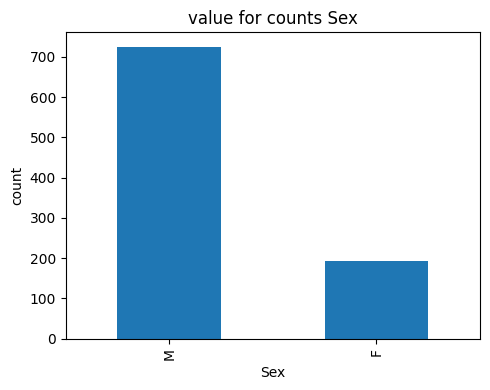

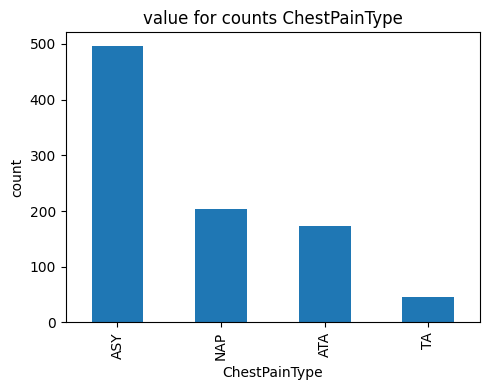

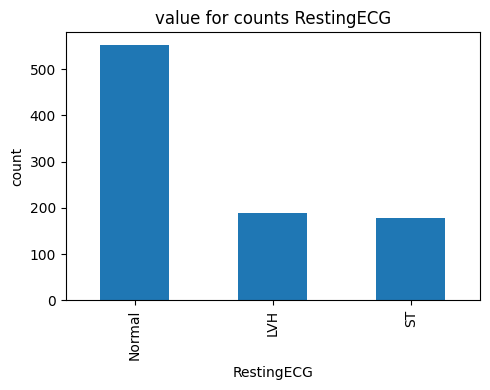

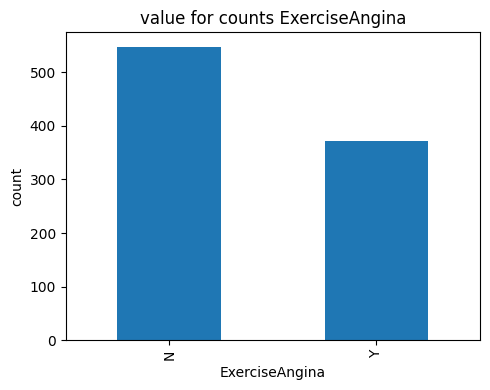

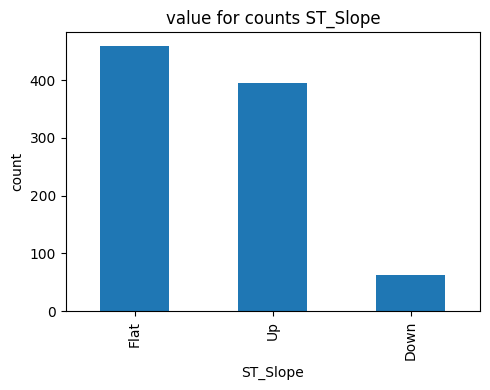

In [41]:
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df_heart[c].value_counts().plot(kind='bar')
  plt.title(f'value for counts {c}')
  plt.ylabel('count')
  plt.tight_layout()
  plt.show()

In [42]:
#label encoding for binary categorical columns
le=LabelEncoder()
df_heart['Sex']=le.fit_transform(df_heart['Sex'])
df_heart['ExerciseAngina']=le.fit_transform(df_heart['ExerciseAngina'])

In [43]:
#onehot encoding for nominal categorical  columns
cat_cols=['ChestPainType','RestingECG','ST_Slope']
df_heart_encoding=pd.get_dummies(
    df_heart,
    columns=cat_cols,
    dtype=int
)

In [44]:
df_heart_encoding.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1


#normalizing and scaling

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#assume df_heart_enconfding
target_Col='HeartDisease'

x=df_heart_encoding.drop(columns=[target_Col])
y=df_heart_encoding[target_Col]

x_train,x_test, y_train,y_test=train_test_split(x,y, test_size=.25, random_state=42)

#standard scaling
scaler_sd= StandardScaler()
x_train_std=scaler_sd.fit_transform(x_train) #mean ans sd will be calculate from x_train
x_test_std=scaler_sd.transform(x_test)

#minmax scaling
scaler_mm=MinMaxScaler()
x_train_mm=scaler_mm.fit_transform(x_train)
x_test_mm=scaler_mm.fit_transform(x_test)

print('\n ---Displayinng standard scaled data--')

#convet scaled arrays back to dataframse for batte visulalization with colums names
x_train_std_df=pd.DataFrame(x_train_std, columns=x_train.columns, index=x_train.index)
x_test_std_df=pd.DataFrame(x_test_std, columns=x_test.columns, index=x_test.index)
print('\n ---first 5 rows of x_train ans x_test(standard scaled--')
display(x_train_std_df.head())
display(x_test_std_df.head())

print('\n ---first 5 rows of x_train (minmax scaled)--')
#convet scaled arrays back to dataframse for batte visulalization with colums names
x_train_mm_df=pd.DataFrame(x_train_mm, columns=x_train.columns, index=x_train.index)
x_test_mm_df=pd.DataFrame(x_test_mm, columns=x_test.columns, index=x_test.index)
print('\n ---Displayinng --')
display(x_train_mm_df.head())
display(x_test_mm_df.head())


 ---Displayinng standard scaled data--

 ---first 5 rows of x_train ans x_test(standard scaled--


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.239292,0.537019,1.183802,1.307314,1.877849,0.551672,1.182037,1.900458,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
362,0.239292,0.537019,1.183802,-1.878000,-0.532524,-1.486343,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
869,0.558968,0.537019,0.913811,0.096522,1.877849,0.831400,-0.845997,0.624033,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
101,-0.293501,0.537019,-0.166155,-0.210833,-0.532524,-1.446382,-0.845997,-0.834739,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
199,0.345851,-1.862131,-0.166155,0.990645,-0.532524,-1.526304,-0.845997,0.076994,-1.104244,-0.480384,-0.530275,4.683304,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.985202,-1.862131,0.373828,-0.061812,-0.532524,1.710544,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
30,-0.080384,0.537019,0.643819,2.946539,-0.532524,-0.247550,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
377,1.198319,0.537019,1.453793,-1.878000,1.877849,-0.567238,-0.845997,0.259340,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
535,0.239292,0.537019,-0.166155,-1.878000,-0.532524,-0.567238,1.182037,0.076994,0.905597,-0.480384,-0.530275,-0.213524,1.978455,-1.225487,-0.494088,-0.254981,0.962897,-0.851064
807,0.026175,0.537019,-1.354116,0.999959,-0.532524,0.791439,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999



 ---first 5 rows of x_train (minmax scaled)--

 ---Displayinng --


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.562500,1.0,0.775,0.567164,1.0,0.674419,1.0,0.636364,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
362,0.562500,1.0,0.775,0.000000,0.0,0.279070,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
869,0.625000,1.0,0.750,0.351575,1.0,0.728682,0.0,0.477273,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
101,0.458333,1.0,0.650,0.296849,0.0,0.286822,0.0,0.295455,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
199,0.583333,0.0,0.650,0.510779,0.0,0.271318,0.0,0.409091,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.729167,0.0,0.500000,0.345745,0.0,0.838028,0.0,0.215686,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
30,0.520833,1.0,0.541667,0.918440,0.0,0.492958,0.0,0.215686,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
377,0.770833,1.0,0.666667,0.000000,1.0,0.436620,0.0,0.450980,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
535,0.583333,1.0,0.416667,0.000000,0.0,0.436620,1.0,0.411765,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
807,0.541667,1.0,0.233333,0.547872,0.0,0.676056,0.0,0.215686,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


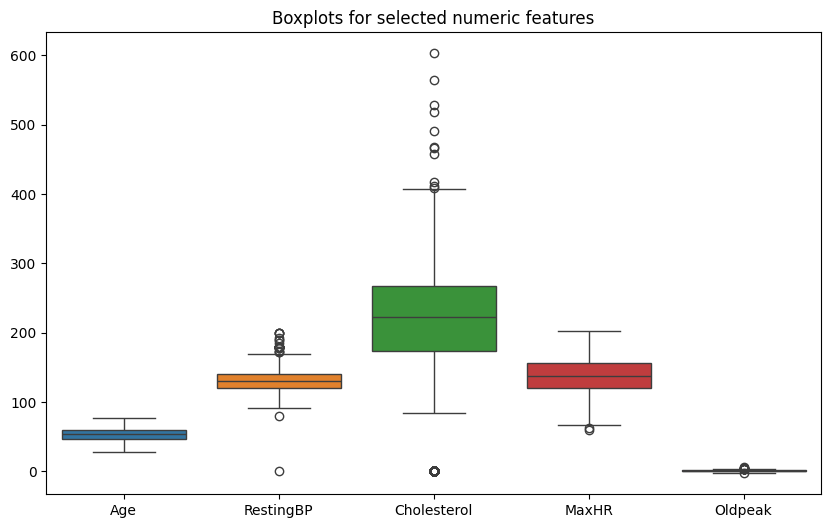

In [46]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as pl
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_heart_encoding[numeric_cols])
plt.title("Boxplots for selected numeric features")
plt.show()

In [47]:
# Use IQR method on Cholesterol as an example
col = "Cholesterol"
Q1 = df_heart_encoding[col].quantile(0.25)
Q3 = df_heart_encoding[col].quantile(0.75)
iqr = Q3-Q1
lower = Q1 -1.5*iqr
upper = Q3 +1.5*iqr

outliers = df_heart_encoding[(df_heart_encoding[col]<lower) | (df_heart_encoding[col]>upper)]
print(f"Numer of detected outliers in {col}: ", len(outliers))

Numer of detected outliers in Cholesterol:  183


In [48]:
#remove outlires
df_no_outliers=df_heart_encoding[(df_heart_encoding[col]>=lower) & (df_heart_encoding[col]<=upper)]
print(f'no outliers:\n{df_no_outliers}')


#2 cap outliers
df_capped=df_heart_encoding.copy()
df_capped[col]=df_capped[col].clip(lower, upper)
print(f'cap outliers:\n{df_capped}')

#3. log transform the coolumn (for skewed)
df_log=df_heart_encoding.copy()
df_log[col+ '_log']= np.log(df_log[col])+1
print(f'log outliers:\n{df_log}')

no outliers:
     Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0     40    1        140          289          0    172               0   
1     49    0        160          180          0    156               0   
2     37    1        130          283          0     98               0   
3     48    0        138          214          0    108               1   
4     54    1        150          195          0    122               0   
..   ...  ...        ...          ...        ...    ...             ...   
913   45    1        110          264          0    132               0   
914   68    1        144          193          1    141               0   
915   57    1        130          131          0    115               1   
916   57    0        130          236          0    174               0   
917   38    1        138          175          0    173               0   

     Oldpeak  HeartDisease  ChestPainType_ASY  ChestPainType_ATA  \
0        0.0      

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


#feature transformation and domain_Driven features

# binging continus to categoriy

In [49]:

from sklearn.preprocessing import PolynomialFeatures
#Polynominal features using age and maxHRd
poly_cols=['Age','MaxHR']
poly=PolynomialFeatures(degree=2, include_bias=False)
poly_features=poly.fit_transform(df_heart_encoding[poly_cols])
poly_feature_names=poly.get_feature_names_out(poly_cols)
print(poly_feature_names)
print(poly_feature_names.shape)

['Age' 'MaxHR' 'Age^2' 'Age MaxHR' 'MaxHR^2']
(5,)


In [50]:
df_heart_encoding['Age_bin']=pd.cut(
    df_heart_encoding['Age'],
    bins=[0,30,50,70,100],
    labels=['Young','Middle','Middle old','Old']

)

print(df_heart_encoding[['Age','Age_bin']].head(50))

    Age     Age_bin
0    40      Middle
1    49      Middle
2    37      Middle
3    48      Middle
4    54  Middle old
5    39      Middle
6    45      Middle
7    54  Middle old
8    37      Middle
9    48      Middle
10   37      Middle
11   58  Middle old
12   39      Middle
13   49      Middle
14   42      Middle
15   54  Middle old
16   38      Middle
17   43      Middle
18   60  Middle old
19   36      Middle
20   43      Middle
21   44      Middle
22   49      Middle
23   44      Middle
24   40      Middle
25   36      Middle
26   53  Middle old
27   52  Middle old
28   53  Middle old
29   51  Middle old
30   53  Middle old
31   56  Middle old
32   54  Middle old
33   41      Middle
34   43      Middle
35   32      Middle
36   65  Middle old
37   41      Middle
38   48      Middle
39   48      Middle
40   54  Middle old
41   54  Middle old
42   35      Middle
43   52  Middle old
44   43      Middle
45   59  Middle old
46   37      Middle
47   50      Middle
48   36      Middle


#doman dribven risk cattegories for restingBp and oldpea

In [51]:

def bp_risk(bp):
  if bp<120:
    return 'Normal'
  elif bp<140:
    return 'Elevated'
  else:
    return 'High'

def oldpeak_risk(op):
  if op<120:
    return 'o stress'
  elif op<140:
    return 'Moderate stress'
  else:
    return 'High Stresss'

df_heart_encoding['BP_Risk']=df_heart_encoding['RestingBP'].apply(bp_risk)
df_heart_encoding['Oldpeak_Risk']=df_heart_encoding['Oldpeak'].apply(oldpeak_risk)

df_heart_encoding[['RestingBP', 'BP_Risk','Oldpeak', 'Oldpeak_Risk']]

,RestingBP,BP_Risk,Oldpeak,Oldpeak_Risk
0,140,High,0.0,o stress
1,160,High,1.0,o stress
2,130,Elevated,0.0,o stress
3,138,Elevated,1.5,o stress
4,150,High,0.0,o stress
...,...,...,...,...
913,110,Normal,1.2,o stress
914,144,High,3.4,o stress
915,130,Elevated,1.2,o stress
916,130,Elevated,0.0,o stress


#pipeline

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import  LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_features = ["Sex", "ExerciseAngina", "ChestPainType", "RestingECG", "ST_Slope"]

#numeric pipline
num_pipeline= Pipeline([
    ('scaler', StandardScaler())
])

#categorical pipeline
cat_pipeline=Pipeline([
    ('ohe',OneHotEncoder(drop='first'))
])

#combine both
preprocess=ColumnTransformer([
    ('num',num_pipeline,num_features),
    ('cat',cat_pipeline,cat_features)
])


#full pipeline witrh a simple model
clf=Pipeline([
    ('prep',preprocess),
    ('mode',LogisticRegression(max_iter=100))
])

## train test split using orginal df_head not already encoded

In [53]:
x=df_heart.drop(columns=[target_Col])
y=df_heart[target_Col]

x_train_pipe, x_test_pipe, y_train_pipe, y_test_pipe=train_test_split(
    x,y,test_size=0.25, random_state=42
)

#fit the full pipeline
clf.fit(x_train_pipe,y_train_pipe)

#predic and evaluate

from sklearn.metrics import accuracy_score
y_pred_pipe= clf.predict(x_test_pipe)
acc= accuracy_score(y_test, y_pred_pipe)
print('logistic regresion with  preprocesssing pipeline', acc)

logistic regresion with  preprocesssing pipeline 0.8434782608695652
